In [4]:
import os

In [9]:
os.chdir('/home/witoslaw/data/diffTSS')
os.getcwd()

'/home/witoslaw/data/diffTSS'

In [6]:
import h5py
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [10]:
#data = h5py.File('data/GM12878_enhancer_promoter_encoding.rna_embedding.hg38.h5')
#data = h5py.File('data/K562_enhancer_promoter_encoding.rna_embedding.hg38.h5')
data = h5py.File('./GM12878_enhancer_promoter_encoding.rna_embedding.hg38.h5')
#data = h5py.File('data/K562_enhancer_promoter_encoding.rna_encoding.hg38.h5')

In [15]:
data.keys()

<KeysViewHDF5 ['activity', 'distance', 'ensid', 'hic', 'pe_code', 'rna']>

In [13]:
for key in data.keys():
    print(data[key][0])

[0.       0.558727 6.092324 0.466036 0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.       0.      ]
[ 0.     13.09   18.9865 86.374  89.266  90.321  90.893   0.      0.
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.      0.      0.      0.      0.      0.
  0.      0.      0.      0.      0.      0.      0.    ]
b'ENSG000003

In [16]:
data['pe_code'].shape

(29077, 61, 2000, 4)

In [ ]:
data['pe_code'][:100, 0]

In [15]:
data['rna'].shape

(29077, 61, 125)

In [16]:
promoter_embedding = data['rna'][:, 0]
promoter_embedding

array([[0.    , 0.    , 0.    , ..., 1.327 , 2.339 , 3.176 ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.4485, 0.3482, 0.1888],
       ...,
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ]])

In [27]:
rna_bins = promoter_embedding.sum(axis=1)
rna_bins

array([ 51.07226, 252.5015 ,  59.5473 , ...,   0.     ,   0.     ,
         0.     ])

(array([2.8919e+04, 5.9000e+01, 1.4000e+01, 1.9000e+01, 1.2000e+01,
        1.5000e+01, 1.3000e+01, 6.0000e+00, 4.0000e+00, 2.0000e+00,
        0.0000e+00, 2.0000e+00, 0.0000e+00, 3.0000e+00, 2.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00]),
 array([     0.        ,   5619.63666667,  11239.27333333,  16858.91      ,
         22478.54666667,  28098.18333333,  33717.82      ,  39337.45666667,
         44957.09333333,  50576.73      ,  56196.36666667,  61816.00333333,
         67435.64      ,  73055.27666667,  78674.91333333,  84294.55      ,
         89914.18666667,  95533.82333333, 101153.46      , 106773.09666667,
        112392.73333333, 118012.37      , 123632.00666667, 129251.64333333,
        134871.28      , 140490.91666667, 146110.55333333, 151730.19      ,
        157349.82666667, 162969.46333333, 168589.1       ]

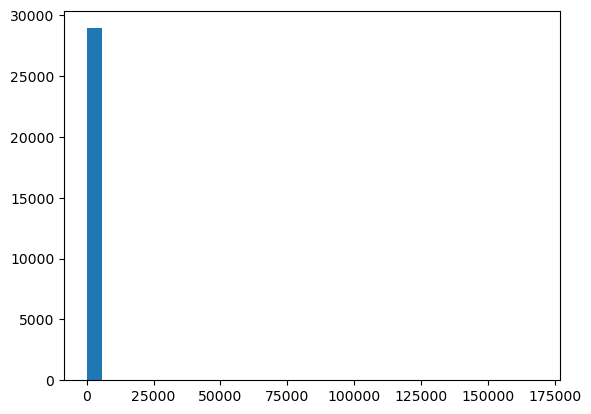

In [28]:
plt.hist(rna_bins, bins=30)

(array([1.6734e+04, 3.4000e+01, 3.1000e+01, 2.0000e+01, 1.9000e+01,
        1.7000e+01, 1.8000e+01, 2.7000e+01, 2.0000e+01, 1.7000e+01,
        2.0000e+01, 2.3000e+01, 2.4000e+01, 1.2000e+01, 2.4000e+01,
        1.7000e+01, 3.1000e+01, 2.0000e+01, 3.6000e+01, 2.5000e+01,
        2.3000e+01, 3.1000e+01, 2.8000e+01, 4.3000e+01, 1.4600e+02,
        4.1000e+01, 5.2000e+01, 6.7000e+01, 1.3000e+02, 1.1347e+04]),
 array([0.        , 0.03333333, 0.06666667, 0.1       , 0.13333333,
        0.16666667, 0.2       , 0.23333333, 0.26666667, 0.3       ,
        0.33333333, 0.36666667, 0.4       , 0.43333333, 0.46666667,
        0.5       , 0.53333333, 0.56666667, 0.6       , 0.63333333,
        0.66666667, 0.7       , 0.73333333, 0.76666667, 0.8       ,
        0.83333333, 0.86666667, 0.9       , 0.93333333, 0.96666667,
        1.        ]),
 <BarContainer object of 30 artists>)

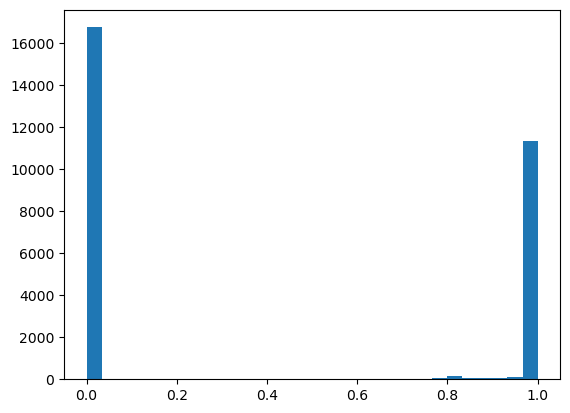

In [30]:
plt.hist(np.tanh(rna_bins), bins=30)

(array([1.7008e+04, 4.4600e+02, 3.9400e+02, 7.7600e+02, 7.5400e+02,
        9.2600e+02, 9.3900e+02, 1.0660e+03, 1.0970e+03, 9.9500e+02,
        8.8000e+02, 8.0100e+02, 6.8500e+02, 5.7700e+02, 5.2100e+02,
        3.3700e+02, 2.4600e+02, 1.5700e+02, 1.3300e+02, 9.0000e+01,
        6.4000e+01, 3.9000e+01, 3.7000e+01, 1.8000e+01, 2.6000e+01,
        2.6000e+01, 2.3000e+01, 5.0000e+00, 7.0000e+00, 4.0000e+00]),
 array([0.        , 0.17422774, 0.34845547, 0.52268321, 0.69691094,
        0.87113868, 1.04536641, 1.21959415, 1.39382188, 1.56804962,
        1.74227736, 1.91650509, 2.09073283, 2.26496056, 2.4391883 ,
        2.61341603, 2.78764377, 2.96187151, 3.13609924, 3.31032698,
        3.48455471, 3.65878245, 3.83301018, 4.00723792, 4.18146565,
        4.35569339, 4.52992113, 4.70414886, 4.8783766 , 5.05260433,
        5.22683207]),
 <BarContainer object of 30 artists>)

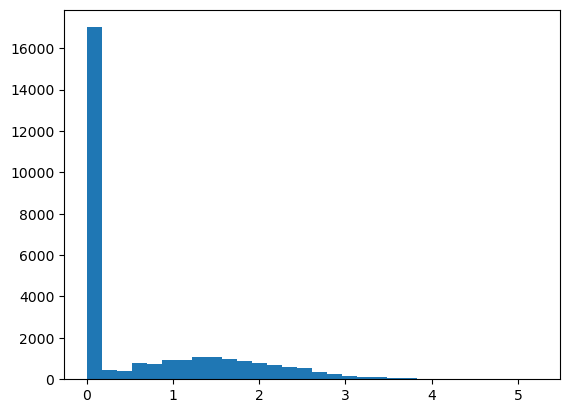

In [32]:
plt.hist(np.log10(rna_bins+1), bins=30)

(array([16768.,    51.,    36.,    42.,    38.,    37.,    34.,    34.,
           30.,    38.,    46.,    27.,    40.,    30.,    43.,   140.,
           37.,    41.,    32.,    33.,    44.,    45.,    51.,    74.,
          368.,    72.,    82.,   113.,   227., 10424.]),
 array([0.5       , 0.51666667, 0.53333333, 0.55      , 0.56666667,
        0.58333333, 0.6       , 0.61666667, 0.63333333, 0.65      ,
        0.66666667, 0.68333333, 0.7       , 0.71666667, 0.73333333,
        0.75      , 0.76666667, 0.78333333, 0.8       , 0.81666667,
        0.83333333, 0.85      , 0.86666667, 0.88333333, 0.9       ,
        0.91666667, 0.93333333, 0.95      , 0.96666667, 0.98333333,
        1.        ]),
 <BarContainer object of 30 artists>)

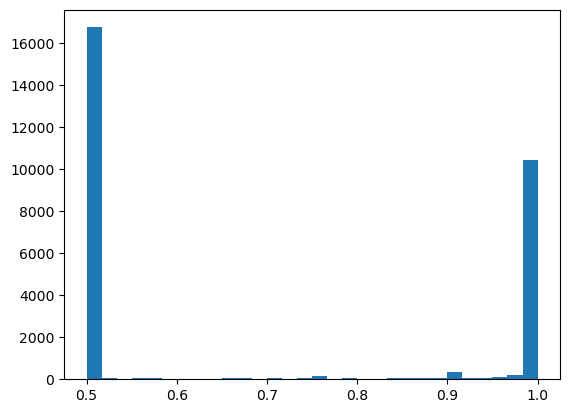

In [33]:
plt.hist(1 / (1 + np.exp(-rna_bins)), bins=30)

In [6]:
#rna = np.array(data['rna'])
data['pe_code'][0]

array([[[1.     , 0.     , 0.     , 0.     , 0.01987],
        [0.     , 0.     , 0.     , 1.     , 0.01987],
        [0.     , 0.     , 0.     , 1.     , 0.01987],
        ...,
        [0.     , 0.     , 0.     , 1.     , 0.     ],
        [1.     , 0.     , 0.     , 0.     , 0.     ],
        [1.     , 0.     , 0.     , 0.     , 0.     ]],

       [[0.     , 0.     , 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , 0.     , 0.     ],
        ...,
        [0.     , 0.     , 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , 0.     , 0.     ]],

       [[0.     , 0.     , 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , 0.     , 0.     ],
        ...,
        [0.     , 0.     , 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , 0.     , 0.     ],
        [0.     , 0.  

In [7]:
rna[:, 0].max(axis=1)

NameError: name 'rna' is not defined

In [ ]:
plt.hist(rna[:, 0].max(axis=1), bins=30)

In [ ]:
plt.hist(np.tanh(rna[:, 0].max(axis=1)), bins=30)

In [ ]:
plt.hist(1 / (1 + np.exp(-rna[:, 0].max(axis=1))), bins=30)

In [ ]:
plt.hist(np.log10(rna[:, 0].max(axis=1) + 1), bins=30)

In [28]:
zero_promoters = []
min_max = []
for i in tqdm(range(len(data['pe_code']))):
    if data['pe_code'][i][0][:,4].max() == 0 and data['pe_code'][i][0].min == 0:
        zero_promoters.append(i)
    min_max.append([data['pe_code'][i][0][:,4].min(), data['pe_code'][i][0][:,4].max()])
len(zero_promoters)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29077/29077 [12:38<00:00, 38.36it/s]


0

In [32]:
len(min_max)

29077